In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = '/kaggle/input/property-salesmelbourne-city/Property Sales of Melbourne City.csv' 

# Set display options for pandas DataFrames
pd.set_option('display.max_columns', None) # Show all columns
pd.set_option('display.width', 1000) # Widen the display output

## 1. Load Data

In [3]:
print(f"--- Loading Data from {file_path} ---")
try:
    df = pd.read_csv(file_path)
    print("Data loaded successfully.")
    print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
except FileNotFoundError:
    print(f"Error: File not found at '{file_path}'.")
    print("Please update the 'file_path' variable in the script.")
    exit() # Exit if the file cannot be loaded
except Exception as e:
    print(f"An error occurred while loading the data: {e}")
    exit()

--- Loading Data from /kaggle/input/property-salesmelbourne-city/Property Sales of Melbourne City.csv ---
Data loaded successfully.
Dataset shape: 18396 rows, 22 columns


## 2. Initial Data Exploration

In [4]:
print("\n--- Initial Data Exploration ---")

# Display the first 5 rows
print("\nFirst 5 rows:")
df.head()


--- Initial Data Exploration ---

First 5 rows:


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Unnamed: 0,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,1,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,3/12/2016,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,2,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,4/02/2016,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,4,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,5,Abbotsford,40 Federation La,3,h,850000,PI,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,6,Abbotsford,55a Park St,4,h,1600000,VB,Nelson,4/06/2016,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [5]:
# Display basic information (data types, non-null counts)
print("\nData Info:")
df.info()


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18396 entries, 0 to 18395
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     18396 non-null  int64  
 1   Suburb         18396 non-null  object 
 2   Address        18396 non-null  object 
 3   Rooms          18396 non-null  int64  
 4   Type           18396 non-null  object 
 5   Price          18396 non-null  int64  
 6   Method         18396 non-null  object 
 7   SellerG        18396 non-null  object 
 8   Date           18396 non-null  object 
 9   Distance       18395 non-null  float64
 10  Postcode       18395 non-null  float64
 11  Bedroom2       14927 non-null  float64
 12  Bathroom       14925 non-null  float64
 13  Car            14820 non-null  float64
 14  Landsize       13603 non-null  float64
 15  BuildingArea   7762 non-null   float64
 16  YearBuilt      8958 non-null   float64
 17  CouncilArea    12233 non-null  object 

In [6]:
# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics (Numerical Features):")
# Use .apply(lambda x: f"{x:,.2f}") to format large numbers for readability if desired
df.describe()


Descriptive Statistics (Numerical Features):


,Unnamed: 0,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,18396.000000,18396.000000,1.839600e+04,18395.000000,18395.000000,14927.000000,14925.000000,14820.000000,13603.000000,7762.000000,8958.000000,15064.000000,15064.000000,18395.000000
mean,11826.787073,2.935040,1.056697e+06,10.389986,3107.140147,2.913043,1.538492,1.615520,558.116371,151.220219,1965.879996,-37.809849,144.996338,7517.975265
std,6800.710448,0.958202,6.419217e+05,6.009050,95.000995,0.964641,0.689311,0.955916,3987.326586,519.188596,37.013261,0.081152,0.106375,4488.416599
min,1.000000,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,5936.750000,2.000000,6.330000e+05,6.300000,3046.000000,2.000000,1.000000,1.000000,176.500000,93.000000,1950.000000,-37.858100,144.931193,4294.000000
50%,11820.500000,3.000000,8.800000e+05,9.700000,3085.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.803625,145.000920,6567.000000
75%,17734.250000,3.000000,1.302000e+06,13.300000,3149.000000,3.000000,2.000000,2.000000,651.000000,174.000000,2000.000000,-37.756270,145.060000,10331.000000
max,23546.000000,12.000000,9.000000e+06,48.100000,3978.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


In [7]:
# Display descriptive statistics for categorical columns
print("\nDescriptive Statistics (Categorical Features):")
df.describe(include=['object']) # 'object' usually indicates strings/categories


Descriptive Statistics (Categorical Features):


,Suburb,Address,Type,Method,SellerG,Date,CouncilArea,Regionname
count,18396,18396,18396,18396,18396,18396,12233,18395
unique,330,18134,3,5,305,58,33,8
top,Reservoir,14 Rose St,h,S,Nelson,27/05/2017,Moreland,Southern Metropolitan
freq,541,3,12095,12034,2002,610,1163,6343


In [8]:
# Display the list of columns
print("\nColumns in the dataset:")
print(df.columns.tolist())


Columns in the dataset:
['Unnamed: 0', 'Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG', 'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude', 'Longtitude', 'Regionname', 'Propertycount']


In [9]:
# Check for missing values
print("\nMissing Values per Column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0]) # Only show columns with missing values


Missing Values per Column:
Distance             1
Postcode             1
Bedroom2          3469
Bathroom          3471
Car               3576
Landsize          4793
BuildingArea     10634
YearBuilt         9438
CouncilArea       6163
Lattitude         3332
Longtitude        3332
Regionname           1
Propertycount        1
dtype: int64


## 3. Basic Data Cleaning


In [10]:
print("\n--- Basic Data Cleaning ---")

# Handle missing values (Example Strategies - CHOOSE WISELY based on your goal)

# Strategy 1: Drop rows with missing essential data (like Price)
if 'Price' in df.columns:
    initial_rows = df.shape[0]
    df.dropna(subset=['Price'], inplace=True)
    print(f"\nDropped {initial_rows - df.shape[0]} rows where 'Price' was missing.")
else:
    print("\nWarning: 'Price' column not found, skipping price-based row removal.")


--- Basic Data Cleaning ---

Dropped 0 rows where 'Price' was missing.


In [11]:
# Strategy 2: Impute missing numerical values (e.g., with median or mean)
# Example: Impute 'BuildingArea', 'Landsize', 'Car', 'Bathroom' with their median
# Median is often preferred over mean for skewed distributions (like price or sizes)
cols_to_impute_median = ['BuildingArea', 'Landsize', 'Car', 'Bathroom','Bedroom2','YearBuilt','Lattitude','Longtitude']
for col in cols_to_impute_median:
    if col in df.columns and df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Imputed missing values in '{col}' with median ({median_val:.2f}).")

Imputed missing values in 'BuildingArea' with median (126.00).
Imputed missing values in 'Landsize' with median (440.00).
Imputed missing values in 'Car' with median (2.00).
Imputed missing values in 'Bathroom' with median (1.00).
Imputed missing values in 'Bedroom2' with median (3.00).
Imputed missing values in 'YearBuilt' with median (1970.00).
Imputed missing values in 'Lattitude' with median (-37.80).
Imputed missing values in 'Longtitude' with median (145.00).


/tmp/ipykernel_555/1763475655.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


In [12]:
# Strategy 3: Impute missing categorical values (e.g., with mode)
# Example: Impute 'CouncilArea' with its mode (most frequent value)
if 'CouncilArea' in df.columns and df['CouncilArea'].isnull().any():
     mode_val = df['CouncilArea'].mode()[0] # mode() returns a Series, get the first element
     df['CouncilArea'].fillna(mode_val, inplace=True)
     print(f"Imputed missing values in 'CouncilArea' with mode ('{mode_val}').")

Imputed missing values in 'CouncilArea' with mode ('Moreland').


/tmp/ipykernel_555/2143257988.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CouncilArea'].fillna(mode_val, inplace=True)


In [13]:
# Note: Other strategies exist (e.g., forward/backward fill for time series, using ML models for imputation)
# You might also choose to drop columns with too many missing values if they aren't critical

print("\nMissing Values after initial handling:")
missing_values_after = df.isnull().sum()
print(missing_values_after[missing_values_after > 0])
# Optional: Drop any remaining rows with NAs if needed (use cautiously)
# df.dropna(inplace=True)
# print("Dropped remaining rows with any NA values.")


Missing Values after initial handling:
Distance         1
Postcode         1
Regionname       1
Propertycount    1
dtype: int64


In [14]:
df.dropna(inplace=True)

In [15]:
# Correct Data Types
print("\nCorrecting Data Types:")
# Convert 'Date' to datetime objects
if 'Date' in df.columns:
    try:
        # Attempt common formats, adjust if your format is different (e.g., '%Y-%m-%d')
        df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce') # DD/MM/YYYY
        # If coerce results in NaT (Not a Time), try another format or investigate source data
        if df['Date'].isnull().any():
             print("Warning: Some dates could not be parsed with format DD/MM/YYYY. Check source format.")
        else:
             print("Converted 'Date' column to datetime objects.")
    except Exception as e:
        print(f"Could not convert 'Date' column to datetime: {e}. Please check the date format in your file.")


Correcting Data Types:
Converted 'Date' column to datetime objects.


In [16]:
# Ensure numerical columns intended for calculation are numeric
# (read_csv usually handles this well, but good practice for columns like Price)
numeric_cols_check = ['Price', 'Rooms', 'Distance', 'Propertycount', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea']
for col in numeric_cols_check:
    if col in df.columns:
        if df[col].dtype == 'object': # If it's read as text (e.g., due to '$' or ',')
             df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[$,]', '', regex=True), errors='coerce')
             print(f"Attempted conversion of '{col}' to numeric.")
        # Ensure integer columns don't become float due to NAs if needed (after imputation)
        if col in ['Rooms', 'Bedroom2', 'Bathroom', 'Car', 'Propertycount'] and pd.api.types.is_numeric_dtype(df[col]):
            # Convert to nullable integer type to handle potential remaining NaNs gracefully
             df[col] = df[col].astype('Int64')

print("\nData Info after Cleaning:")
df.info()


Data Info after Cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 18395 entries, 0 to 18395
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Unnamed: 0     18395 non-null  int64         
 1   Suburb         18395 non-null  object        
 2   Address        18395 non-null  object        
 3   Rooms          18395 non-null  Int64         
 4   Type           18395 non-null  object        
 5   Price          18395 non-null  int64         
 6   Method         18395 non-null  object        
 7   SellerG        18395 non-null  object        
 8   Date           18395 non-null  datetime64[ns]
 9   Distance       18395 non-null  float64       
 10  Postcode       18395 non-null  float64       
 11  Bedroom2       18395 non-null  Int64         
 12  Bathroom       18395 non-null  Int64         
 13  Car            18395 non-null  Int64         
 14  Landsize       18395 non-null  float64       
 1

## 4. Exploratory Data Analysis (EDA) & Visualization


In [17]:
print("\n--- Generating Visualizations ---")
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6)) # Set default figure size for upcoming plots


--- Generating Visualizations ---


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


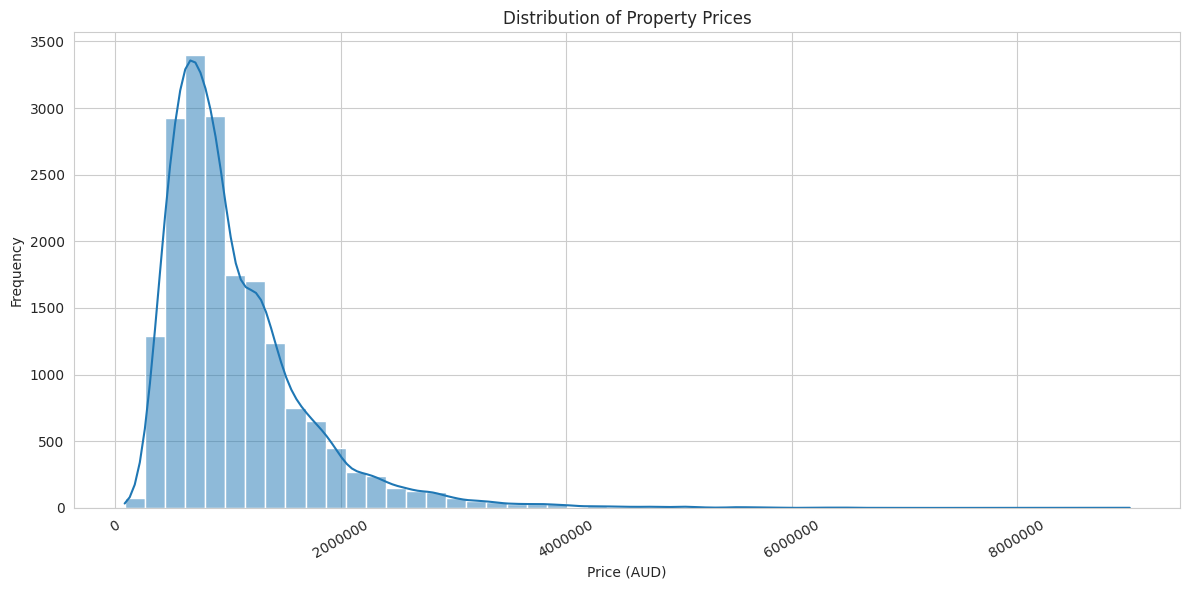

In [18]:
# --- Univariate Analysis ---

# Distribution of Price (Histogram & KDE)
if 'Price' in df.columns and pd.api.types.is_numeric_dtype(df['Price']):
    plt.figure(figsize=(12, 6))
    sns.histplot(df['Price'], kde=True, bins=50)
    plt.title('Distribution of Property Prices')
    plt.xlabel('Price (AUD)')
    plt.ylabel('Frequency')
    plt.ticklabel_format(style='plain', axis='x') # Avoid scientific notation
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

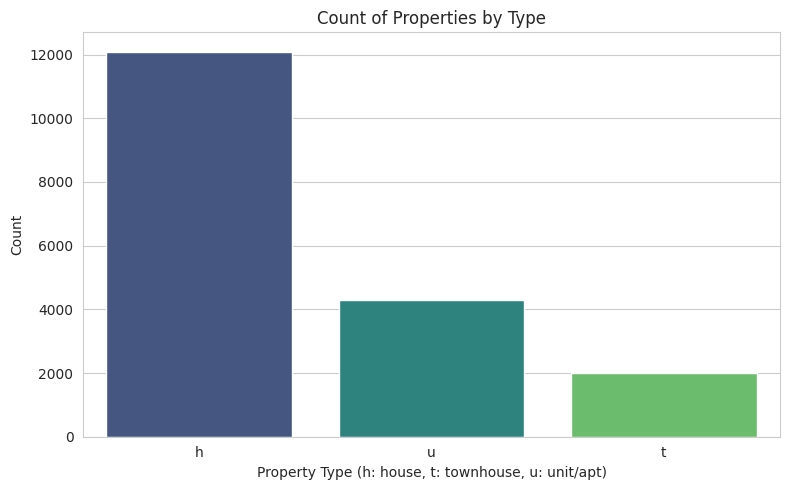

In [19]:
# Count of Properties by Type
if 'Type' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(x='Type', data=df, order=df['Type'].value_counts().index, palette='viridis')
    plt.title('Count of Properties by Type')
    plt.xlabel('Property Type (h: house, t: townhouse, u: unit/apt)')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

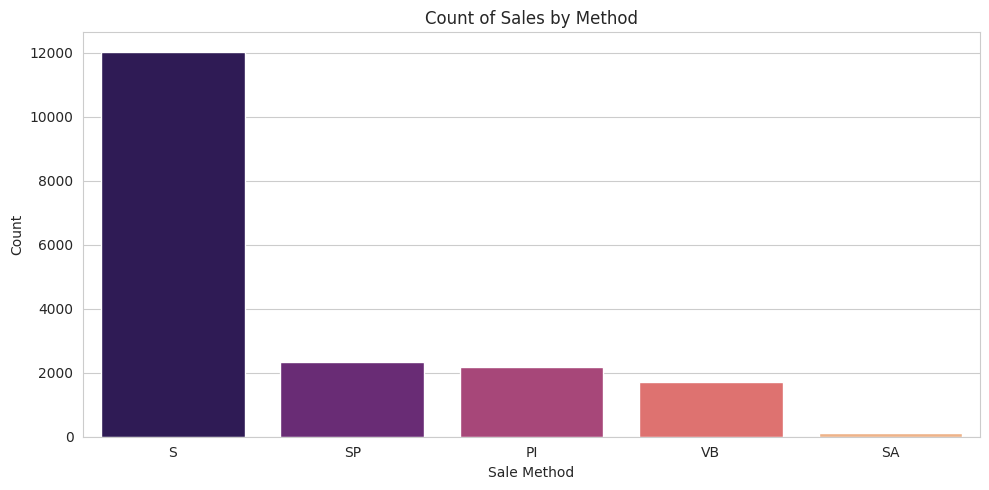

In [20]:
# Count of Sales Methods
if 'Method' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(x='Method', data=df, order=df['Method'].value_counts().index, palette='magma')
    plt.title('Count of Sales by Method')
    plt.xlabel('Sale Method')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


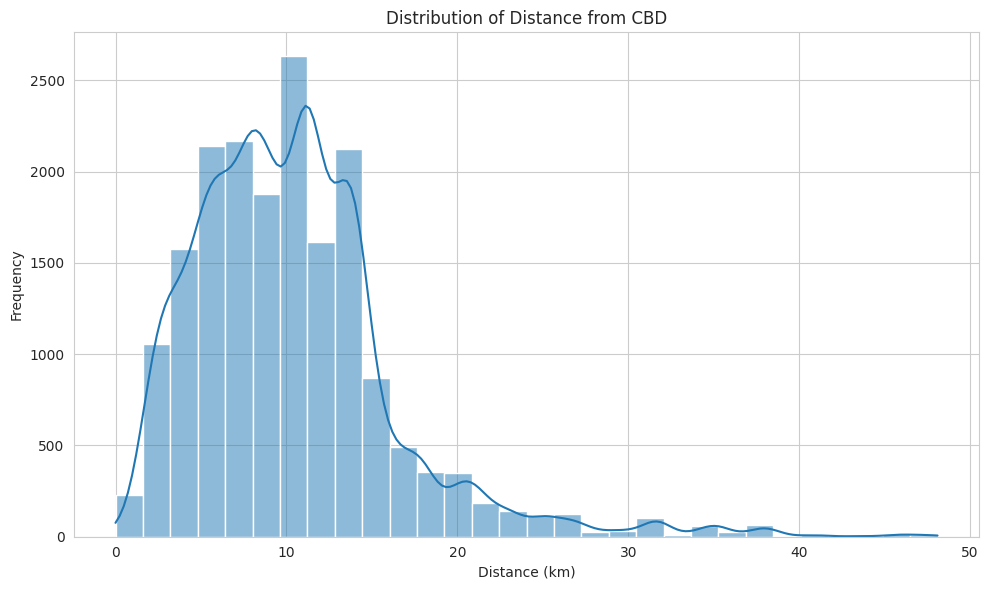

In [21]:
# Distribution of Distance from CBD
if 'Distance' in df.columns and pd.api.types.is_numeric_dtype(df['Distance']):
    plt.figure(figsize=(10, 6))
    sns.histplot(df['Distance'], kde=True, bins=30)
    plt.title('Distribution of Distance from CBD')
    plt.xlabel('Distance (km)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

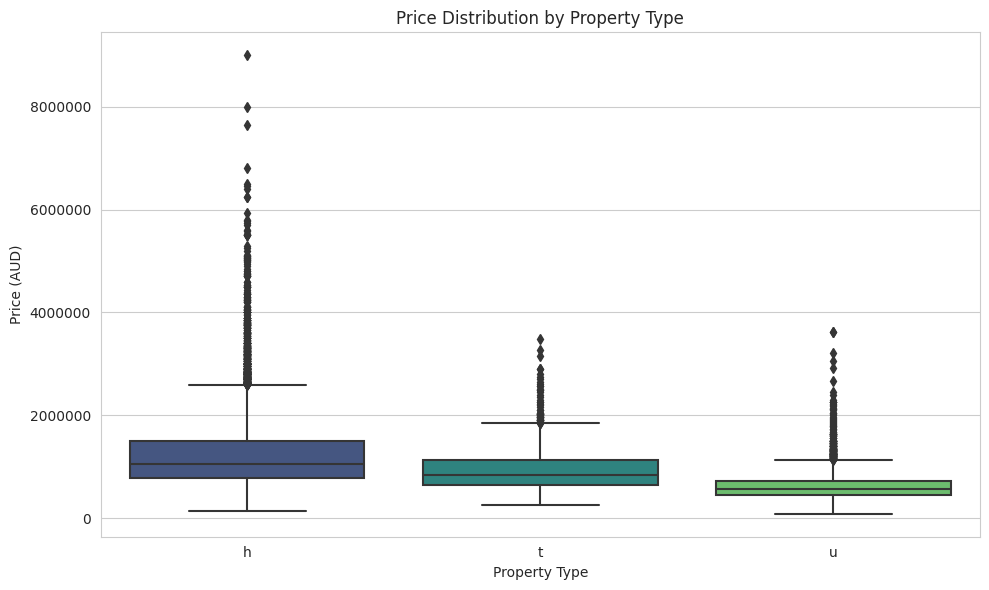

In [22]:
# --- Bivariate Analysis ---

# Price vs. Property Type (Box Plot)
if 'Price' in df.columns and 'Type' in df.columns and pd.api.types.is_numeric_dtype(df['Price']):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Type', y='Price', data=df, palette='viridis')
    plt.title('Price Distribution by Property Type')
    plt.xlabel('Property Type')
    plt.ylabel('Price (AUD)')
    plt.ticklabel_format(style='plain', axis='y')
    plt.tight_layout()
    plt.show()

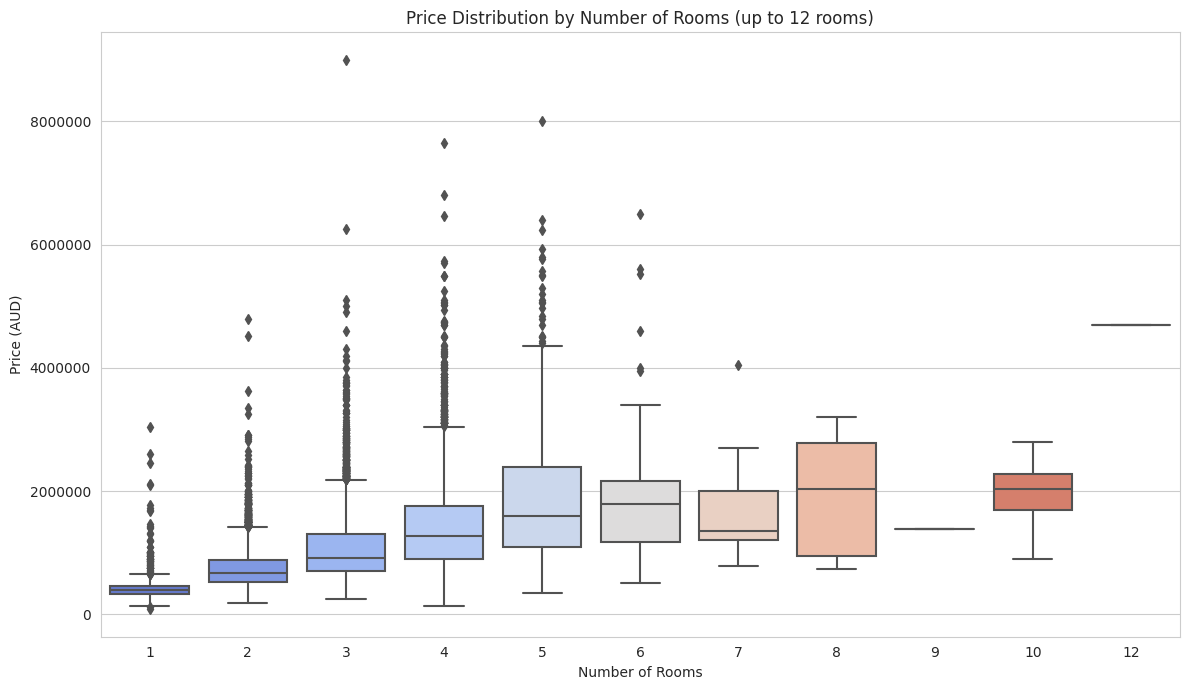

In [23]:
# Price vs. Number of Rooms (Box Plot)
if 'Price' in df.columns and 'Rooms' in df.columns and pd.api.types.is_numeric_dtype(df['Price']):
    plt.figure(figsize=(12, 7))
    # Limit rooms for better visualization if there are many outliers
    room_limit = df['Rooms'].quantile(0.99) if df['Rooms'].nunique() > 15 else df['Rooms'].max()
    sns.boxplot(x='Rooms', y='Price', data=df[df['Rooms'] <= room_limit], palette='coolwarm')
    plt.title(f'Price Distribution by Number of Rooms (up to {int(room_limit)} rooms)')
    plt.xlabel('Number of Rooms')
    plt.ylabel('Price (AUD)')
    plt.ticklabel_format(style='plain', axis='y')
    plt.tight_layout()
    plt.show()

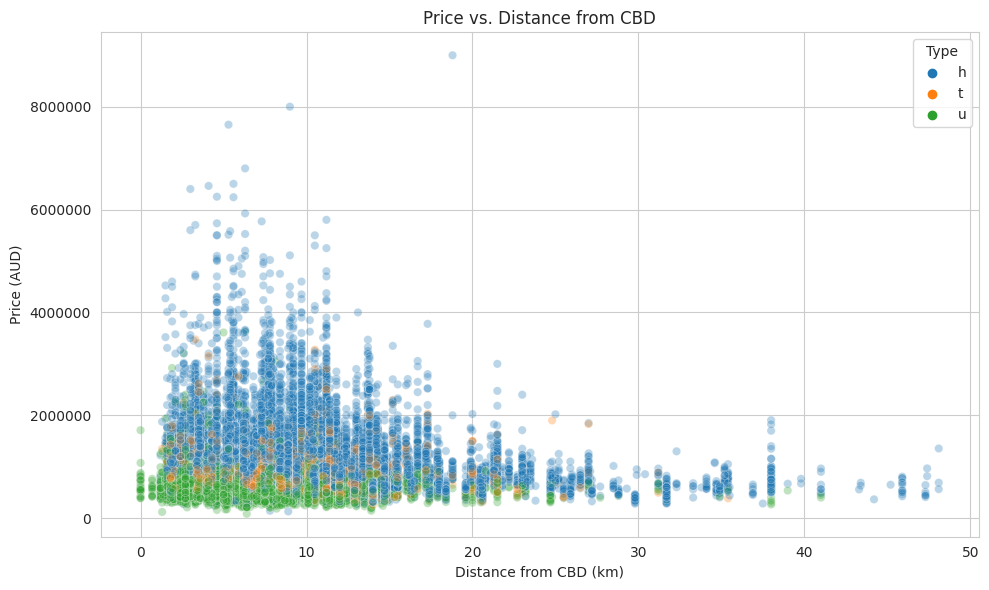

In [24]:
# Price vs. Distance from CBD (Scatter Plot)
if 'Price' in df.columns and 'Distance' in df.columns and pd.api.types.is_numeric_dtype(df['Price']) and pd.api.types.is_numeric_dtype(df['Distance']):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Distance', y='Price', data=df, alpha=0.3, hue='Type' if 'Type' in df.columns else None)
    plt.title('Price vs. Distance from CBD')
    plt.xlabel('Distance from CBD (km)')
    plt.ylabel('Price (AUD)')
    plt.ticklabel_format(style='plain', axis='y')
    plt.tight_layout()
    plt.show()

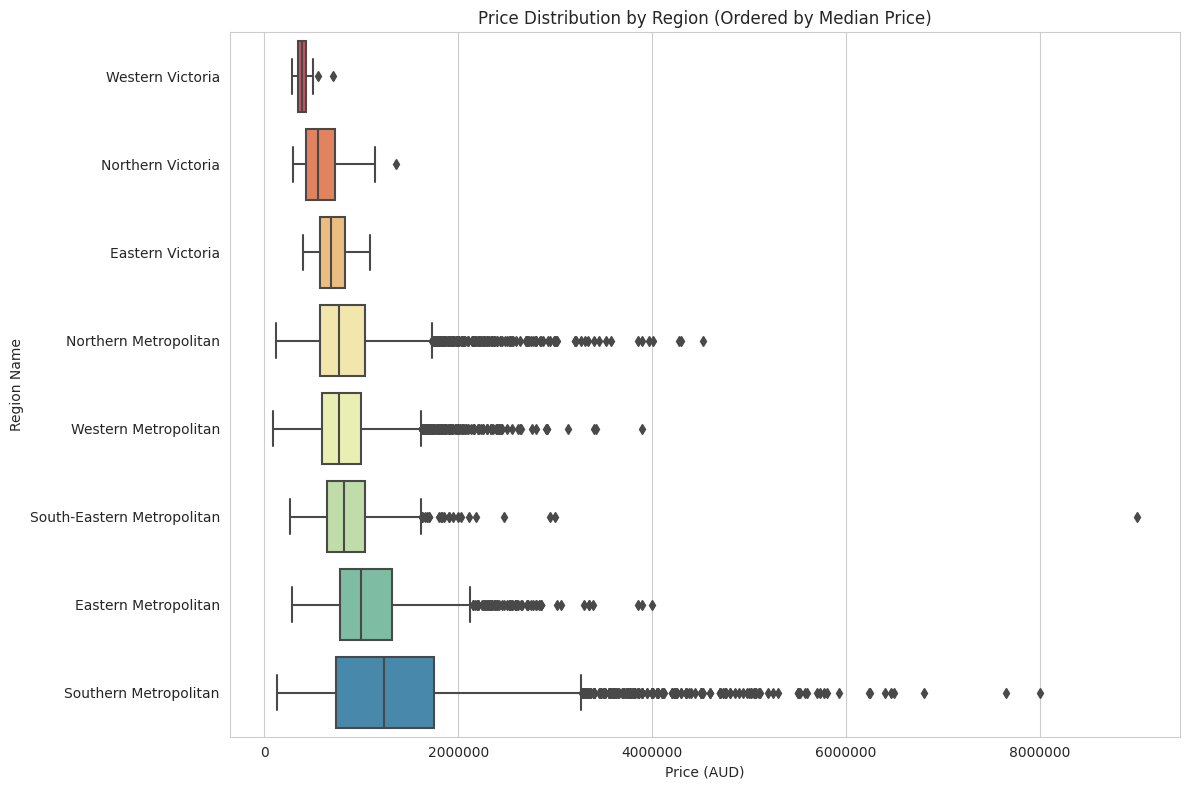

In [25]:
# Price vs. Regionname (Box Plot)
if 'Price' in df.columns and 'Regionname' in df.columns and pd.api.types.is_numeric_dtype(df['Price']):
    plt.figure(figsize=(12, 8))
    region_order = df.groupby('Regionname')['Price'].median().sort_values().index
    sns.boxplot(y='Regionname', x='Price', data=df, order=region_order, palette='Spectral', orient='h')
    plt.title('Price Distribution by Region (Ordered by Median Price)')
    plt.ylabel('Region Name')
    plt.xlabel('Price (AUD)')
    plt.ticklabel_format(style='plain', axis='x')
    plt.tight_layout()
    plt.show()

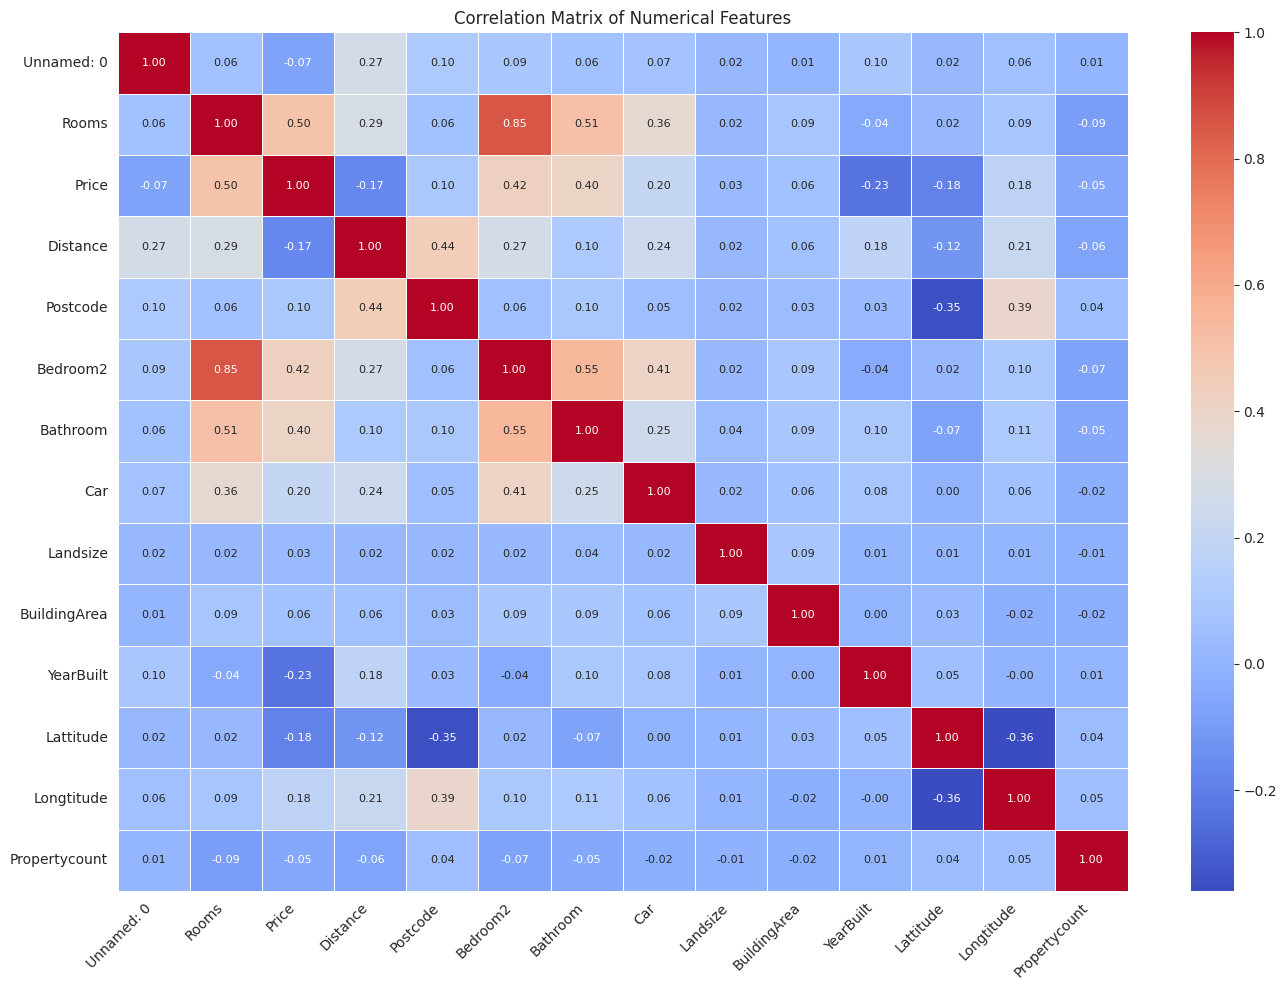

In [26]:
# --- Correlation Analysis ---
if any(pd.api.types.is_numeric_dtype(df[col]) for col in df.columns):
    plt.figure(figsize=(14, 10))
    # Select only numeric columns for correlation calculation
    numeric_df = df.select_dtypes(include=np.number)
    # Drop columns that might not be useful for correlation (like IDs or counts if they are constant)
    # Example: drop Propertycount if it's just metadata per suburb
    # numeric_df = numeric_df.drop(columns=['Propertycount'], errors='ignore')
    correlation_matrix = numeric_df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 8})
    plt.title('Correlation Matrix of Numerical Features')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


--- Time Series Analysis ---


/tmp/ipykernel_555/2520483196.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg_price = df_time['Price'].resample('M').mean() # 'M' for month end, 'MS' for month start
/tmp/ipykernel_555/2520483196.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales_count = df_time['Price'].resample('M').count()


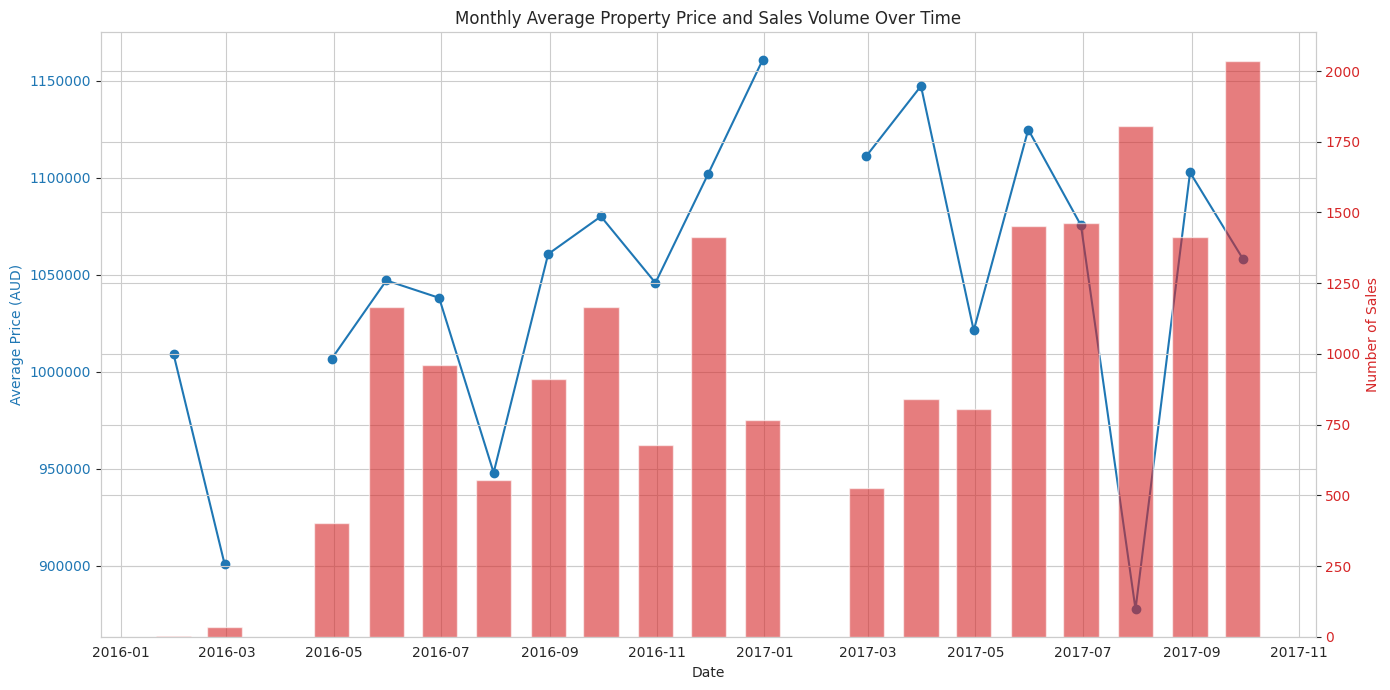

In [27]:
# --- Time Series Analysis (Optional) ---
if 'Date' in df.columns and pd.api.types.is_datetime64_any_dtype(df['Date']) and 'Price' in df.columns:
    print("\n--- Time Series Analysis ---")
    # Ensure data is sorted by date for meaningful resampling
    df_time = df.sort_values('Date').set_index('Date')

    # Resample data (e.g., monthly average price)
    try:
        monthly_avg_price = df_time['Price'].resample('M').mean() # 'M' for month end, 'MS' for month start
        monthly_sales_count = df_time['Price'].resample('M').count()

        fig, ax1 = plt.subplots(figsize=(14, 7))

        color = 'tab:blue'
        ax1.set_xlabel('Date')
        ax1.set_ylabel('Average Price (AUD)', color=color)
        ax1.plot(monthly_avg_price.index, monthly_avg_price.values, color=color, marker='o', linestyle='-')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.ticklabel_format(style='plain', axis='y')

        ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
        color = 'tab:red'
        ax2.set_ylabel('Number of Sales', color=color)
        ax2.bar(monthly_sales_count.index, monthly_sales_count.values, color=color, alpha=0.6, width=20)
        ax2.tick_params(axis='y', labelcolor=color)

        plt.title('Monthly Average Property Price and Sales Volume Over Time')
        fig.tight_layout()  # otherwise the right y-label is slightly clipped
        plt.show()

    except Exception as e:
        print(f"Error during time series resampling/plotting: {e}")
else:
    print("\nSkipping time series analysis: 'Date' column not found or not in datetime format, or 'Price' missing.")

<Axes: xlabel='SellerG'>

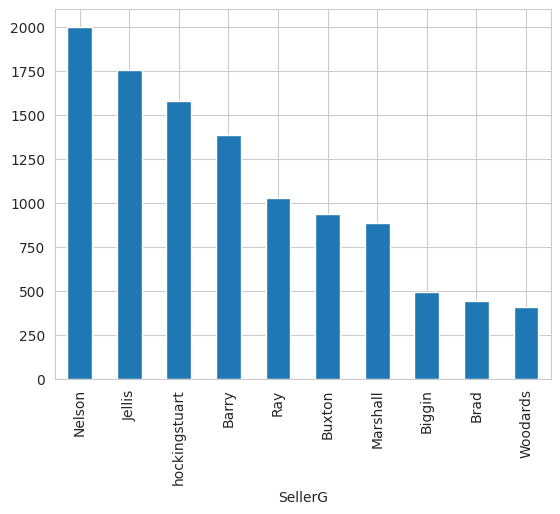

In [28]:
# - Top Seller Agencies: 
df['SellerG'].value_counts().head(10).plot(kind='bar')

<Axes: ylabel='CouncilArea'>

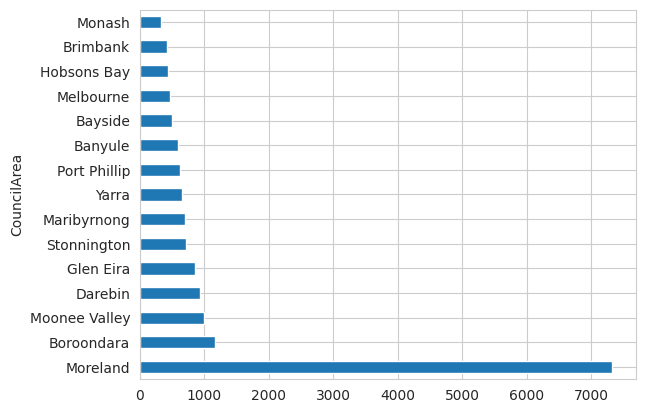

In [29]:
# - Properties per Council Area: 
df['CouncilArea'].value_counts().head(15).plot(kind='barh')

<Axes: xlabel='Landsize', ylabel='BuildingArea'>

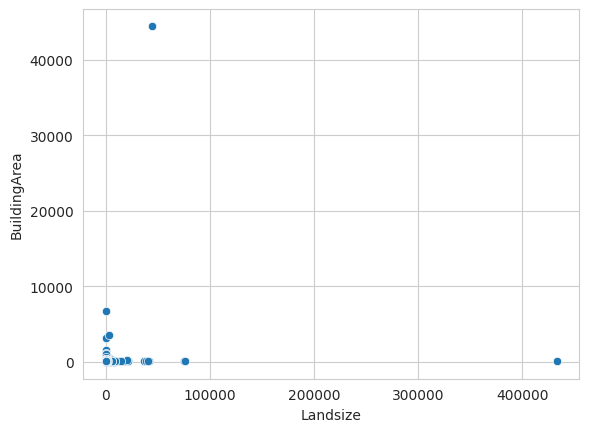

In [30]:
# - Landsize vs BuildingArea: 
sns.scatterplot(x='Landsize', y='BuildingArea', data=df)

## 5. Predicting prices

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [32]:
# Define the target variable
target = 'Price'

In [33]:
# Convert 'Date' to datetime and extract features
if 'Date' in df.columns:
    try:
        df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
        df.dropna(subset=['Date'], inplace=True) # Drop rows where date conversion failed
        df['Year'] = df['Date'].dt.year
        df['Month'] = df['Date'].dt.month
        # Optional: Calculate property age if 'YearBuilt' column existed
        # df['Age'] = df['Year'] - df['YearBuilt']
        print("Extracted 'Year' and 'Month' from 'Date'.")
    except Exception as e:
        print(f"Could not process 'Date' column: {e}. It will be excluded from features.")
        if 'Year' in df.columns: df = df.drop(columns=['Year'])
        if 'Month' in df.columns: df = df.drop(columns=['Month'])

Extracted 'Year' and 'Month' from 'Date'.


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18395 entries, 0 to 18395
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Unnamed: 0     18395 non-null  int64         
 1   Suburb         18395 non-null  object        
 2   Address        18395 non-null  object        
 3   Rooms          18395 non-null  Int64         
 4   Type           18395 non-null  object        
 5   Price          18395 non-null  int64         
 6   Method         18395 non-null  object        
 7   SellerG        18395 non-null  object        
 8   Date           18395 non-null  datetime64[ns]
 9   Distance       18395 non-null  float64       
 10  Postcode       18395 non-null  float64       
 11  Bedroom2       18395 non-null  Int64         
 12  Bathroom       18395 non-null  Int64         
 13  Car            18395 non-null  Int64         
 14  Landsize       18395 non-null  float64       
 15  BuildingArea   18395 non

In [35]:
df.head()

,Unnamed: 0,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Year,Month
0,1,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,2016-12-03,2.5,3067.0,2,1,1,202.0,126.0,1970.0,Yarra,-37.7996,144.9984,Northern Metropolitan,4019,2016,12
1,2,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,2016-02-04,2.5,3067.0,2,1,0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019,2016,2
2,4,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,2017-03-04,2.5,3067.0,3,2,0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019,2017,3
3,5,Abbotsford,40 Federation La,3,h,850000,PI,Biggin,2017-03-04,2.5,3067.0,3,2,1,94.0,126.0,1970.0,Yarra,-37.7969,144.9969,Northern Metropolitan,4019,2017,3
4,6,Abbotsford,55a Park St,4,h,1600000,VB,Nelson,2016-06-04,2.5,3067.0,3,1,2,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019,2016,6


In [36]:
df.describe()

,Unnamed: 0,Rooms,Price,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount,Year,Month
count,18395.000000,18395.0,1.839500e+04,18395,18395.000000,18395.000000,18395.0,18395.0,18395.0,18395.000000,18395.000000,18395.000000,18395.000000,18395.000000,18395.0,18395.000000,18395.000000
mean,11826.423050,2.935091,1.056716e+06,2017-02-11 09:22:22.734438656,10.389986,3107.140147,2.929437,1.436912,1.690242,527.346398,136.641987,1967.993640,-37.808722,144.997168,7517.975265,2016.562164,7.151128
min,1.000000,1.0,8.500000e+04,2016-01-28 00:00:00,0.000000,3000.000000,0.0,0.0,0.0,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.0,2016.000000,1.000000
25%,5936.500000,2.0,6.330000e+05,2016-09-17 00:00:00,6.300000,3046.000000,2.0,1.0,1.0,250.500000,126.000000,1970.000000,-37.845400,144.950935,4294.0,2016.000000,5.000000
50%,11820.000000,3.0,8.800000e+05,2017-03-18 00:00:00,9.700000,3085.000000,3.0,1.0,2.0,440.000000,126.000000,1970.000000,-37.803625,145.000920,6567.0,2017.000000,7.000000
75%,17733.000000,3.0,1.302000e+06,2017-07-08 00:00:00,13.300000,3149.000000,3.0,2.0,2.0,596.000000,126.000000,1970.000000,-37.767400,145.046900,10331.0,2017.000000,9.000000
max,23546.000000,12.0,9.000000e+06,2017-09-23 00:00:00,48.100000,3978.000000,20.0,8.0,10.0,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.0,2017.000000,12.000000
std,6800.716076,0.958203,6.419340e+05,NaN,6.009050,95.000995,0.869625,0.655666,0.871392,3429.215200,337.475238,25.910549,0.073477,0.096279,4488.416599,0.496134,2.488375


In [37]:
df.describe(include=object)

,Suburb,Address,Type,Method,SellerG,CouncilArea,Regionname
count,18395,18395,18395,18395,18395,18395,18395
unique,329,18133,3,5,305,33,8
top,Reservoir,14 Rose St,h,S,Nelson,Moreland,Southern Metropolitan
freq,541,3,12095,12033,2002,7325,6343


In [38]:
# 2. --- Select features for the model ---
# Numerical features to potentially use
numerical_features = [
    'Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea',
    'Propertycount','Lattitude','Longtitude','YearBuilt','Year', 'Month' # Add extracted date features if available
]
# Categorical features to potentially use
ohe_categorical_features = [
    'Type', 'Method', 'Regionname'
]
le_categorical_features = [
  'Suburb','CouncilArea', 'SellerG' 
]

In [39]:
# Keep only selected features and the target variable
features_to_keep = numerical_features + ohe_categorical_features + le_categorical_features + [target]
df_model = df[features_to_keep].copy()

In [40]:
print(f"\nSelected features for modeling: {numerical_features + ohe_categorical_features + le_categorical_features}")
print(f"Target variable: {target}")
print(f"Shape of data for modeling: {df_model.shape}")


Selected features for modeling: ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'Propertycount', 'Lattitude', 'Longtitude', 'YearBuilt', 'Year', 'Month', 'Type', 'Method', 'Regionname', 'Suburb', 'CouncilArea', 'SellerG']
Target variable: Price
Shape of data for modeling: (18395, 19)


In [41]:
# 3. --- Data Preprocessing ---
print("\n--- Data Preprocessing ---")

# Separate features (X) and target (y)
X = df_model.drop(target, axis=1)
y = df_model[target]


--- Data Preprocessing ---


In [42]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training set shape: X_train=(14716, 18), y_train=(14716,)
Testing set shape: X_test=(3679, 18), y_test=(3679,)


In [43]:
# Create preprocessing pipelines for numerical and categorical features

# Pipeline for numerical features:
# 1. Impute missing values using the median
# 2. Scale features using StandardScaler
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [44]:
# Pipeline for categorical features:
# 1. Impute missing values using the most frequent value
# 2. Apply OneHotEncoder (handle unknown categories encountered during testing)
ohe_categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # sparse=False for easier handling later if needed
])



In [45]:
from sklearn.base import BaseEstimator, TransformerMixin # For custom transformer

class PipelineLabelEncoder(BaseEstimator, TransformerMixin):
    """
    Custom LabelEncoder wrapper for Scikit-learn pipelines.
    Handles multiple columns passed as a NumPy array, missing values
    (assumes imputed beforehand), and unseen values during transform.
    """
    def __init__(self):
        # Store encoders indexed by the column index (0, 1, 2...)
        self.encoders_ = {}

    def fit(self, X, y=None):
        # X is likely a NumPy array here from the previous pipeline step (e.g., SimpleImputer)
        n_features = X.shape[1]
        for i in range(n_features):
            # Ensure data is string type for LabelEncoder, handle potential non-strings
            # SimpleImputer should have dealt with NaNs, but astype(str) is robust
            column_data = X[:, i].astype(str)
            # Fit on unique values found in the training data + a placeholder for unknowns
            unique_values = np.unique(column_data).tolist()
            le = LabelEncoder()
            # Add placeholder for unknowns
            le.fit(unique_values + ['__UNKNOWN__'])
            self.encoders_[i] = le
        return self

    def transform(self, X, y=None):
        # X is likely a NumPy array
        # Initialize output array with integer type, matching input shape
        X_transformed = np.empty(X.shape, dtype=int)
        n_features = X.shape[1]
        for i in range(n_features):
            le = self.encoders_[i]
            # Ensure data is string type
            column_data = X[:, i].astype(str)

            # Create a boolean mask for values in the current column NOT seen during fit
            # np.isin checks for membership efficiently
            unseen_mask = ~np.isin(column_data, le.classes_)

            # Use the mask to replace unseen values with the placeholder '__UNKNOWN__'
            # Important: Modify a copy or work with column_data directly if it's safe
            # Here, we apply the mask to column_data before transformation
            column_data[unseen_mask] = '__UNKNOWN__'

            # Apply the fitted encoder to the modified column data
            try:
                X_transformed[:, i] = le.transform(column_data)
            except ValueError as e:
                # This catch might be needed if somehow '__UNKNOWN__' wasn't fitted, though it should be
                print(f"Warning: ValueError during transform in LabelEncoder for column index {i}: {e}")
                # Handle error case - perhaps assign a default value like -1 or 0
                # Forcing unknown to a specific code (e.g., the code for '__UNKNOWN__')
                unknown_code = le.transform(['__UNKNOWN__'])[0]
                transformed_col = np.full(X.shape[0], unknown_code) # Default to unknown code
                # Try transforming known values
                known_mask = np.isin(column_data, le.classes_)
                if np.any(known_mask):
                     transformed_col[known_mask] = le.transform(column_data[known_mask])
                X_transformed[:, i] = transformed_col


        return X_transformed

In [46]:
# Pipeline for many categorical features:
# 1. Impute missing values using the most frequent value
# 2. Apply LabelEncoder
le_categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Impute first
    ('label_encoder', PipelineLabelEncoder()) # Use custom LabelEncoder wrapper
])

In [47]:
# Create a ColumnTransformer to apply different pipelines to different columns
# Identify numerical and categorical columns *within the selected features*
numerical_cols = [col for col in numerical_features if col in X.columns]
ohe_categorical_cols = [col for col in ohe_categorical_features if col in X.columns]
le_categorical_cols = [col for col in le_categorical_features if col in X.columns]

preprocessor = ColumnTransformer(
    transformers=[
        ('le_cat', le_categorical_pipeline, le_categorical_cols),
        ('cat', ohe_categorical_pipeline, ohe_categorical_cols),
        ('num', numerical_pipeline, numerical_cols),

    ],
    remainder='passthrough' # Keep other columns (if any) - should be none in this setup
)

In [48]:
# 4. --- Model Training ---
print("\n--- Model Training ---")

# Define the model - RandomForestRegressor
# n_estimators: number of trees in the forest
# random_state: ensures reproducibility
# n_jobs=-1: use all available CPU cores
# max_depth: limits the depth of trees (can help prevent overfitting)
# min_samples_split/leaf: minimum samples required to split/be at a leaf node
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=20, min_samples_split=10, min_samples_leaf=5, oob_score=True)


--- Model Training ---


In [49]:
# Create the full pipeline including preprocessing and the model
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', model)
])

# Train the model
print("Training the RandomForestRegressor model...")
full_pipeline.fit(X_train, y_train)
print("Model training completed.")

# Display OOB score (Out-of-Bag score) - an estimate of performance on unseen data using leftover samples during bootstrap aggregating
if hasattr(full_pipeline.named_steps['regressor'], 'oob_score_') and full_pipeline.named_steps['regressor'].oob_score:
     print(f"Model Out-of-Bag (OOB) R^2 score: {full_pipeline.named_steps['regressor'].oob_score_:.4f}")

Training the RandomForestRegressor model...
Model training completed.
Model Out-of-Bag (OOB) R^2 score: 0.7673


In [50]:
# --- 5. Prediction ---
print("\n--- Making Predictions on Test Set ---")
y_pred = full_pipeline.predict(X_test)


--- Making Predictions on Test Set ---


In [51]:
# --- 6. Evaluation ---
# Interpretation:
# MAE: Average absolute difference between predicted and actual prices.
# RMSE: Square root of the average squared difference. Sensitive to large errors. Similar units to the target.
# R²: Proportion of the variance in the dependent variable that is predictable from the independent variables. Ranges from 0 to 1 (or negative for poor models). Higher is better.
print("\n--- Model Evaluation ---")

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Evaluation Metrics on the Test Set:")
print(f"  Mean Absolute Error (MAE):      ${mae:,.2f}")
print(f"  Mean Squared Error (MSE):       {mse:,.2f}")
print(f"  Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"  R-squared (R²) Score:           {r2:.4f}")


--- Model Evaluation ---
Evaluation Metrics on the Test Set:
  Mean Absolute Error (MAE):      $167,594.68
  Mean Squared Error (MSE):       80,241,019,434.29
  Root Mean Squared Error (RMSE): $283,268.46
  R-squared (R²) Score:           0.8032



--- Feature Importance ---
Top 20 Features by Importance:
                                  Feature  Importance
16                               Method_S    0.236259
19                              Method_VB    0.228107
20        Regionname_Eastern Metropolitan    0.160998
23           Regionname_Northern Victoria    0.066855
5                            BuildingArea    0.055990
3                                     Car    0.029314
27            Regionname_Western Victoria    0.028887
24  Regionname_South-Eastern Metropolitan    0.026952
26        Regionname_Western Metropolitan    0.026180
25       Regionname_Southern Metropolitan    0.024100
11                                  Month    0.021738
0                                   Rooms    0.018284
21            Regionname_Eastern Victoria    0.015379
2                                Bathroom    0.011185
28                                 Suburb    0.009594
30                                SellerG    0.008474
1                      

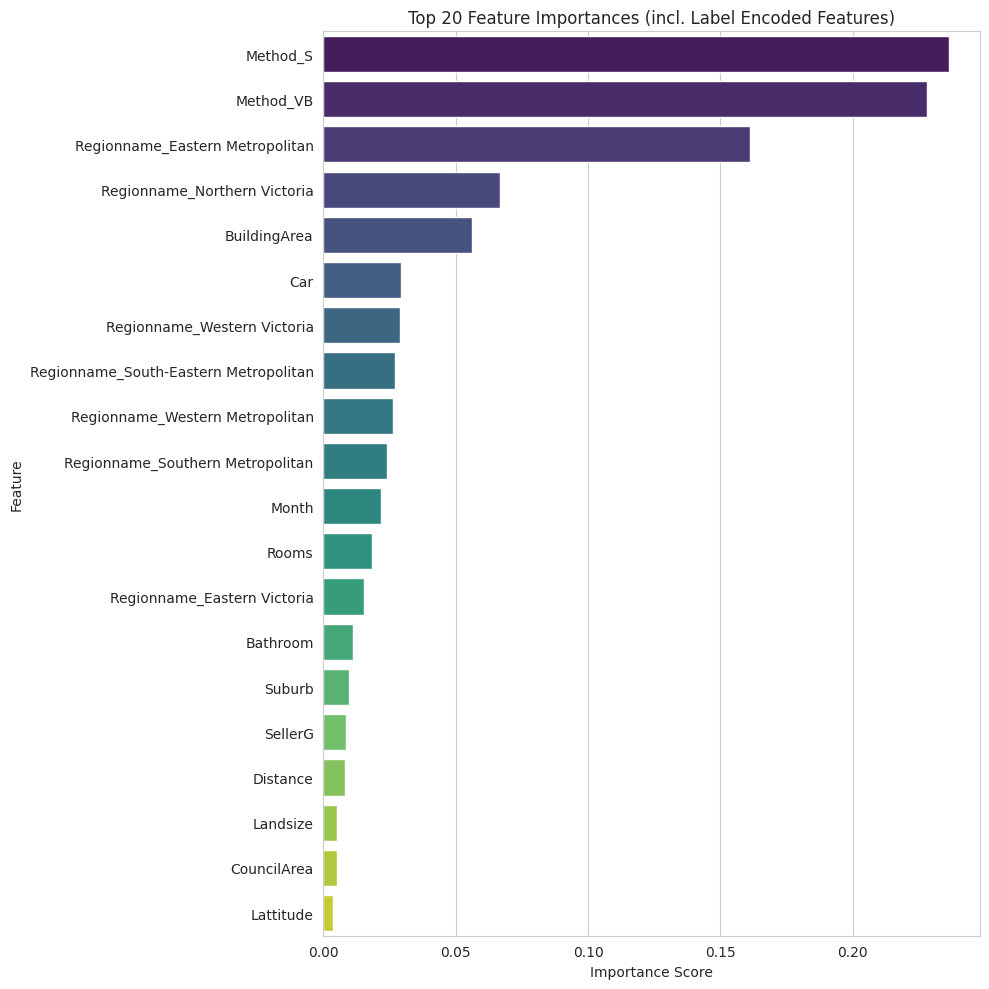

In [52]:
# --- 7. Feature Importance ---
# (Keep feature importance code the same - it should still work as the
# order and names derived should match the output of the preprocessor)
print("\n--- Feature Importance ---")
try:
    # Get feature names after transformation
    ohe_transformer = full_pipeline.named_steps['preprocessor'].transformers_[1][1] # Access OHE pipeline
    ohe_feature_names = ohe_transformer.named_steps['onehot'].get_feature_names_out(ohe_categorical_features)

    le_feature_names = le_categorical_features # Label Encoded features keep original names in list
    num_feature_names = numerical_features # Numerical features keep original names

    # Combine all feature names in the order they appear AFTER transformation
    feature_names_out = list(num_feature_names) + list(ohe_feature_names) + list(le_feature_names)

    importances = full_pipeline.named_steps['regressor'].feature_importances_

    if len(feature_names_out) == len(importances):
        feature_importance_df = pd.DataFrame({
            'Feature': feature_names_out,
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)

        print("Top 20 Features by Importance:")
        print(feature_importance_df.head(20))

        # Plot feature importances
        plt.figure(figsize=(10, 10))
        sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')
        plt.title('Top 20 Feature Importances (incl. Label Encoded Features)')
        plt.xlabel('Importance Score')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Warning: Mismatch in feature name count ({len(feature_names_out)}) and importance count ({len(importances)}). Skipping feature importance plot.")
        # Debugging info:
        print("Num features:", num_feature_names)
        print("OHE features:", ohe_feature_names)
        print("LE features:", le_feature_names)


except Exception as e:
    print(f"Could not retrieve or plot feature importances: {e}")



In [53]:
# --- 8. Example Prediction (Optional) ---
# Create a sample data point (ensure it has the same columns as X_train)
# Note: This requires creating a DataFrame with the correct column names *before* preprocessing
if not X_train.empty:
    print("\n--- Example Prediction ---")
    try:
        sample_data = X_train.iloc[[0]].copy() # Take the first row of the training data as an example
        print("Sample Input Data (first row of training data):")
        print(sample_data)

        # Use the trained pipeline to predict on this sample
        sample_prediction = full_pipeline.predict(sample_data)
        actual_value = y_train.iloc[0]

        print(f"\nPredicted Price for the sample: ${sample_prediction[0]:,.2f}")
        print(f"Actual Price for the sample:    ${actual_value:,.2f}")
    except Exception as e:
        print(f"Could not generate example prediction: {e}")


--- Example Prediction ---
Sample Input Data (first row of training data):
       Rooms  Distance  Bathroom  Car  Landsize  BuildingArea  Propertycount  Lattitude  Longtitude  YearBuilt  Year  Month Type Method            Regionname    Suburb CouncilArea  SellerG
16276      3      14.7         2    1     440.0         126.0          16166  -37.89318   144.64149     1970.0  2017      9    h      S  Western Metropolitan  Werribee    Moreland  Sweeney

Predicted Price for the sample: $473,950.71
Actual Price for the sample:    $471,000.00
